In [1]:
%load_ext autoreload
%autoreload 2
import os
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
import PIL.Image as Image

from mylib.plot import plot_imgs

/home/mattia/miniconda3/envs/keypoint_factory/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loss not decreasing as before
# AUC non changing, I broke something during the backawrd pass :(
# remove caching and looping+stack -> indexing
# write genric module, and specialized modules as child classes

In [3]:
# TODO:
# - try LM with door dataset
# - inspect where highest residuals are located
# - think a way to remove non-common point from edges:
    # - save some vg_edge mask from vg computation and use it during loss computation or in batched steps,
    # basiccaly I dont want points on non repeaded edges. 

In [4]:
# from my datset
# with BA: vienna_mozart_satue, vienna_grillparzer, vienna_state_opera, klagenfurt_dragon, trieste_teatro_romano, munich_frauenkirche

scene = "vienna_state_opera"
reconstruction_path = f"/home/mattia/Desktop/Repos/vggt/wrapper_output/{scene}/sparse" 
images_path = f"/home/mattia/Desktop/datasets/mydataset/data/{scene}/frames" 
depths_path = f"/home/mattia/Desktop/Repos/vggt/wrapper_output/{scene}/sparse/depth_maps"
sky_mask_path = f"/home/mattia/Desktop/datasets/mydataset/data/{scene}/depth_masks_mask2former"
gt_path=f"/home/mattia/Desktop/datasets/mydataset/data/{scene}/colmap/sparse/0" 
# viewgraph_path=f"/home/mattia/Desktop/datasets/mydataset/data/{scene}/colmap/viewgraph_50.txt"
viewgraph_path = None

# scene = "door"
# reconstruction_path = f"/home/mattia/Desktop/Repos/vggt/wrapper_output/{scene}/sparse" 
# images_path = f"/home/mattia/Desktop/Repos/wrapper_factory/benchmarks_3D/eth3d/{scene}/images_by_k" 
# depths_path = f"/home/mattia/Desktop/Repos/vggt/wrapper_output/{scene}/sparse/depth_maps"
# sky_mask_path = f"/home/mattia/Desktop/datasets/mydataset/data/{scene}/depth_masks"
# gt_path=f"/home/mattia/Desktop/Repos/wrapper_factory/benchmarks_3D/eth3d/{scene}/sparse" 

In [5]:
from adjuster import Adjuster
adjuster = Adjuster(
    reconstruction_path = reconstruction_path,
    images_path = images_path,
    depths_path = depths_path,
    # sky_mask_path = sky_mask_path,
    single_camera_per_folder=True,
    load_with_pad=False,
    lr=5e-3,
    grad_q=True,
    grad_t=True,
    grad_k=True,
    grad_z=True,
    matcher_type="frustums",  # or "exhaustive", "sequential"
    scheduler_params={"factor":0.75, "patience":2, "min_lr":1e-4},
    detector_params={"low_threshold":0.20, "high_threshold":0.25, "kernel_size":7, "sigma":2},
    # gt_path=gt_path, # slows down a bit the optimization but useful for eval
    viz=True, 
    use_amp=True,
)

adjuster.print_summary()

CannyEdgeDetector initialized with low_threshold=0.2, high_threshold=0.25, hysteresis=True, kernel_size=7, sigma=2, device=cuda

Found 106 images in /home/mattia/Desktop/datasets/mydataset/data/vienna_state_opera/frames


Extracting edges: 100%|██████████| 106/106 [00:00<00:00, 196.01it/s]


Max edges per image: 12,173


Computing viewgraph: 100%|██████████| 3971/3971 [00:11<00:00, 331.04it/s]


Filtered viewgraph: 2,161 pairs retained


Computing distance fields: 100%|██████████| 106/106 [00:04<00:00, 21.81it/s]



Total parameters to optimize:
  k:                8 parameters
  t:              318 parameters
  q:              424 parameters
  z:        1,290,338 parameters
  Total:    1,291,088 parameters

Using scheduler: ReduceLROnPlateau with params: {'factor': 0.75, 'patience': 2, 'min_lr': 0.0001}

                             Summary                              
------------------------------------------------------------------
Stage                           Time (s)        %    Per Iter
------------------------------------------------------------------
load_images                         1.05     5.5%            
load_poses_and_intrinsics           0.06     0.3%            
extract_edges                       0.54     2.9%            
load_depth_maps                     0.12     0.6%            
compute_viewgraph                  12.13    64.1%            
compute_distance_fields             4.94    26.1%            
prepare_batched_inputs              0.00     0.0%            
batched

dict_keys(['image', 'coords', 'scale', 'hw', 'cam_id', 'edges_map', 'edges', 'edges_padded', 'pad_mask', 'depth', 'sampled_depth', 'dt_field'])


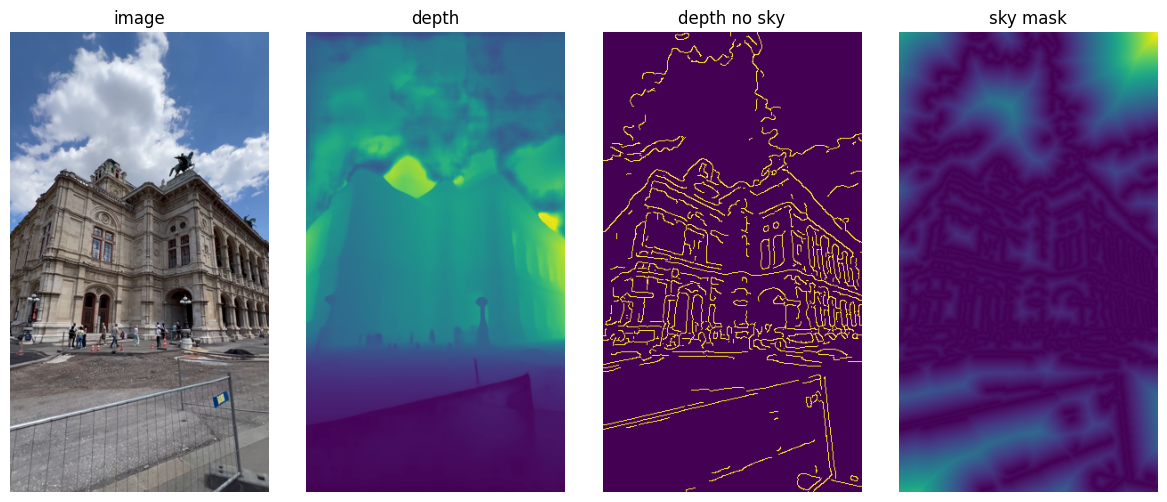

torch.Size([10078, 2])


In [6]:
from mylib.plot import plot_imgs

k = list(adjuster.images.keys())[0]
print(adjuster.images[k].keys())

plot_imgs([
    adjuster.images[k]['image'].permute(1,2,0).cpu() if 'image' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).permute(1,2,0).cpu(),
    adjuster.images[k]['depth'].cpu() if 'depth' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu(),
    # adjuster.images[k]['depth_no_sky'].cpu() if 'depth_no_sky' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu(),
    # adjuster.images[k]['sky_mask'].cpu() if 'sky_mask' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu(),
    adjuster.images[k]['edges_map'].cpu() if 'edges_map' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu(),
    adjuster.images[k]['dt_field'].cpu() if 'dt_field' in adjuster.images[k] else torch.zeros_like(adjuster.images[k]['depth']).cpu(),
], titles=[
    "image",
    "depth",
    "depth no sky",
    "sky mask",
    "edges map",
    "dt field",
])

print(adjuster.images[k]['edges'].cpu().shape)

In [7]:
adjuster( 
    batch_size=128, 
    max_steps=-1,
)

Processing 2,161 pairs with batch size 128 (17 batches per iteration) Using 12,173 edges per image
Total points to process per iteration: 26,305,853.
Initial learning rate: 5.00e-03.
Target learning rate:  1.00e-04.


Adjusting poses and intrinsics:  26%|██▌       | 258/1000 [01:11<03:24,  3.63it/s, auc5=0, loss=3.3205, lr=1.00e-04]

Learning rate reached minimum threshold 1.00e-04 <= 1.00e-04. Stopping optimization.

                             Summary                              
------------------------------------------------------------------
Stage                           Time (s)        %    Per Iter
------------------------------------------------------------------
load_images                         1.05     1.2%            
load_poses_and_intrinsics           0.06     0.1%            
extract_edges                       0.54     0.6%            
load_depth_maps                     0.12     0.1%            
compute_viewgraph                  12.13    13.5%            
compute_distance_fields             4.94     5.5%            
total_optimization                 71.02    79.0%            
prepare_batched_inputs                                   0.0149
batched_reprojection                                     0.0077
batched_loss_computation                                 0.0001
gradient_computation     

/tmp/ipykernel_2331356/3443556276.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


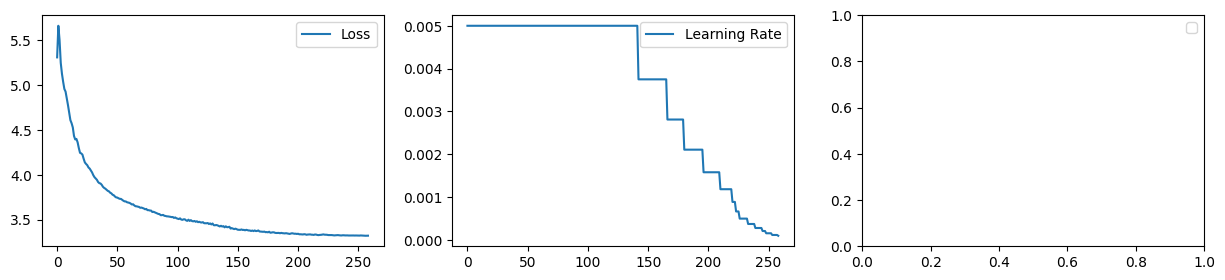

In [8]:
from matplotlib import pyplot as plt
import numpy as np
auc = np.array(adjuster.auc_list)
# plot loss and lr side by side
plt.figure(figsize=(15,3))
plt.subplot(1, 3, 1)
plt.plot(adjuster.loss_list, label='Loss')
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(adjuster.lr_list, label='Learning Rate')
plt.legend()
plt.subplot(1, 3, 3)
for i, th in enumerate([1,3,5]):
    plt.plot(auc[:,i], label=f'AUC@{th}px') if len(auc) > 0 else None
plt.legend()
plt.show()

In [9]:
opt = f"/home/mattia/Desktop/Repos/batchsfm/optimized_reconstruction_GD/{scene}"
os.makedirs(opt, exist_ok=True)
adjuster.to_colmap(
    opt, 
    verbose=False, 
    max_points_per_image=100_000//len(adjuster.images), 
    save_points=True, 
    final_dbscan_filtering=True, 
    dbscan_eps=0.075, dbscan_min_samples=5
)

Reconstruction(num_cameras=2, num_images=106, num_reg_images=106, num_points3D=0)

In [10]:
import sys
sys.path.append('/home/mattia/Desktop/Repos/wrapper_factory/benchmarks_3D')
from benchmark_pose import eval_colmap_model

thresholds = [1,3,5]
print("AUC@",thresholds)
AUC_score_max, num_images, df_initial = eval_colmap_model(reconstruction_path, gt_path, return_df=True, thrs=thresholds)
print("VGGT AUC:   ",AUC_score_max)

try:
    ba = f"/home/mattia/Desktop/Repos/vggt/wrapper_output/{scene}/sparse_ba"
    # ba = f"/home/mattia/Desktop/Repos/wrapper_factory/benchmarks_3D/results/vggt_ba/synth/{scene}/sparse_ba"
    AUC_score_max, num_images, df_ba = eval_colmap_model(ba, gt_path, return_df=True, thrs=thresholds)
    print("VGGT+BA AUC:",AUC_score_max)
except:
    print("No BA reconstruction found.")
    
AUC_score_max, num_images, df_optim = eval_colmap_model(opt, gt_path, return_df=True, thrs=thresholds)
print("VGGT+EA AUC:",AUC_score_max)

AUC@ [1, 3, 5]
VGGT AUC:    [ 2.54272887 33.33578117 55.169623  ]
VGGT+BA AUC: [14.85512241 38.48551366 54.60318652]
VGGT+EA AUC: [28.15403858 68.73327233 79.26142474]


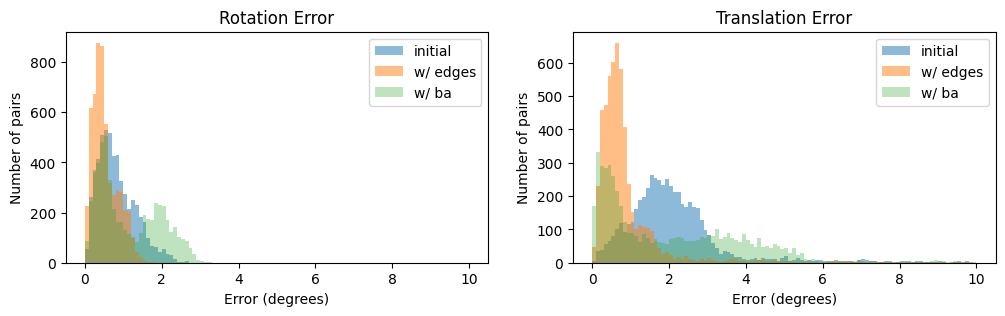

In [11]:
if True:
    # df_initial.hist(["q_error", "t_error"], bins=100, range=(0, 10)) anbd df_optim.hist(["q_error", "t_error"], bins=100, range=(0, 10)) but overlapping
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,3))
    plt.subplot(1,2,1)
    plt.hist(df_initial.q_error, bins=100, range=(0,10), alpha=0.5, label='initial')
    plt.hist(df_optim.q_error, bins=100, range=(0,10), alpha=0.5, label='w/ edges')
    try:
        plt.hist(df_ba.q_error, bins=100, range=(0,10), alpha=0.3, label='w/ ba')
    except NameError:
        pass
    plt.title('Rotation Error')
    plt.xlabel('Error (degrees)')
    plt.ylabel('Number of pairs')
    plt.legend()
    plt.subplot(1,2,2)
    plt.hist(df_initial.t_error, bins=100, range=(0,10), alpha=0.5, label='initial')
    plt.hist(df_optim.t_error, bins=100, range=(0,10), alpha=0.5, label='w/ edges')
    try:
        plt.hist(df_ba.t_error, bins=100, range=(0,10), alpha=0.3, label='w/ ba')
    except NameError:
        pass
    plt.title('Translation Error')
    plt.xlabel('Error (degrees)')
    plt.ylabel('Number of pairs')
    plt.legend()
    plt.show()

In [12]:
from pathlib import Path

# adjuster.visualize_residuals(output_dir=Path(opt)/"residual_maps", max_images=1)

In [13]:
.
# sequential: 11.75s/step
# with all operation batches 2.4s/step
# with caching un project to 3D: 2.2s/step
# with caching unproject to world: 1.87s/step
# with right batched (256 -> 128) projection: 1.8s/step
# wo auc: 1.23s/step
# removing some loops: 0.42s/step roughly 6,850 edges/s

SyntaxError: invalid syntax (3632660206.py, line 1)

In [ ]:
from mylib.plot import plot_imgs

print(len(viewgraph))
i,j = viewgraph[2000]
print(i, j)

i, j = '13/IMG_4697_frame_000001.jpg', '13/IMG_4697_frame_000003.jpg'

plot_imgs([images[i]['image'].permute(1,2,0).cpu(), images[j]['image'].permute(1,2,0).cpu()])

In [ ]:
plot_imgs([images[i]['edges_map'], images[j]['edges_map']], cmap="gray")

In [ ]:
plot_imgs([images[i]['depth'], images[j]['depth']], cmap="plasma")

In [ ]:
# plot_imgs([images[i]['dt_field'], images[j]['dt_field']], cmap="plasma")

In [ ]:
x1,y1,x2,y2,h,w = [int(x) for x in images[i]['coords']]
img1 = images[i]['image'][:, y1:y2, x1:x2]
img2 = images[j]['image'][:, y1:y2, x1:x2]
edge1 = images[i]['edges_map'][y1:y2, x1:x2]
edge2 = images[j]['edges_map'][y1:y2, x1:x2]
Z1 = images[i]['depth'][y1:y2, x1:x2][None]
Z2 = images[j]['depth'][y1:y2, x1:x2][None]

edge1.shape, edge2.shape, img1.shape, img2.shape, Z1.shape, Z2.shape

In [ ]:
from helpers.reprojection import compute_121_reprojection

data = {
    'P0': images[i]['P'].projection_matrix()[None], 
    'P1': images[j]['P'].projection_matrix()[None],
    'K0': intrinsics[images[i]['cam_id']].intrinsic_matrix()[None],  
    'K1': intrinsics[images[j]['cam_id']].intrinsic_matrix()[None],
    'depth0': Z1, 
    'depth1': Z2
}

kpts1, kpts2, tot = compute_121_reprojection(
    data,
    img1, img2,
    verbose=False, reprojection_error=3.0, border=5, sampling_factor=1)

print(f"Consistent points: {len(kpts1):,}, {len(kpts2):,} out of {tot:,} ({100*len(kpts1)/tot:.4f}%)")

In [ ]:
edge1_kpts = edge1.nonzero().flip(dims=(0,1))
edge2_kpts = edge2.nonzero().flip(dims=(0,1))

edge1_kpts.shape, edge2_kpts.shape

In [ ]:
from mylib.plot import plot_imgs_and_kpts

plot_imgs_and_kpts(
    edge1[..., None].repeat(1,1,3).cpu()*255//1,
    edge2[..., None].repeat(1,1,3).cpu()*255//1,
    edge1_kpts, edge2_kpts,
    sample_points=1_000, matches=False,
) 

In [ ]:
from losses.loss import sample_distance_field

dist = sample_distance_field(images[j]['dt_field'], images[i]['edges']).cpu()
print(f"Loss: {dist.mean():.4f}, dist length: {len(dist):,}, edges length: {len(images[i]['edges']):,}")

field = torch.zeros_like(images[j]['dt_field']).cpu()
for pt, d in zip(images[i]['edges'].long(), dist):
    field[pt[1], pt[0]] = d
plt.imshow(field, cmap="magma")

In [ ]:
for image_i, image_j in viewgraph[:10]:
    print(image_i, image_j)